# Efeito causal de ações sobre churn com DML

Este notebook estima, em dados históricos, o efeito médio de cada ação contra um grupo de controle. Para churn binário e tratamento binário por comparação, usamos `DoubleMLIRM`: outcome e propensão podem ser não lineares e são ajustados com cross-fitting.

**Importante:** DML reduz viés de regularização; não resolve confundimento não observado, causalidade reversa, falta de overlap ou interferência. Todas as covariáveis devem existir antes da decisão da ação.

## 1. Configuração

Altere somente esta célula primeiro. `CONTROL_VALUE` deve significar nenhuma ação/oferta usual. `FEATURE_COLUMNS` deve conter causas pré-tratamento tanto da escolha da ação quanto do churn. Não inclua adesão, resposta à campanha, cancelamento ou qualquer variável posterior à ação.

In [1]:
from pathlib import Path

DATA_PATH = Path("../data/churn.csv")  # relativo a este notebook
OUTCOME_COLUMN = "churn_90d"           # deve ser 0/1
ACTION_COLUMN = "acao"
CONTROL_VALUE = "controle"
ACTION_VALUES = None  # None = todas exceto controle; ou ["desconto", "contato"]
FEATURE_COLUMNS = [
    "tenure", "complaints", "usage_change", "score_pre"
]
CATEGORICAL_COLUMNS = []
CLUSTER_COLUMN = None  # ex.: "loja_id"; útil para interferência parcial
SCORE_COLUMN = "score_pre"
SCORE_WINDOW = None  # ex.: (0.40, 0.60); None usa toda a população com overlap
N_FOLDS = 5
RANDOM_STATE = 42
TRIMMING_THRESHOLD = 0.02


In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from doubleml import DoubleMLData, DoubleMLIRM
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carregar e validar

O notebook não inventa dados quando o arquivo não existe: ajuste o caminho e o esquema, para evitar confundir uma demonstração simulada com evidência sobre seus clientes.

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
required = {OUTCOME_COLUMN, ACTION_COLUMN, *FEATURE_COLUMNS}
if CLUSTER_COLUMN:
    required.add(CLUSTER_COLUMN)
missing = required.difference(df.columns)
if missing:
    raise ValueError(f"Colunas ausentes: {sorted(missing)}")
if not set(df[OUTCOME_COLUMN].dropna().unique()).issubset({0, 1}):
    raise ValueError(f"{OUTCOME_COLUMN} deve estar codificada como 0/1")
if CONTROL_VALUE not in set(df[ACTION_COLUMN].dropna()):
    raise ValueError(f"Controle {CONTROL_VALUE!r} não aparece em {ACTION_COLUMN}")

analysis = df.dropna(subset=[OUTCOME_COLUMN, ACTION_COLUMN, *FEATURE_COLUMNS]).copy()
if SCORE_WINDOW is not None:
    lo, hi = SCORE_WINDOW
    analysis = analysis[analysis[SCORE_COLUMN].between(lo, hi)].copy()

actions = ACTION_VALUES or sorted(set(analysis[ACTION_COLUMN]) - {CONTROL_VALUE})
print(f"N analítico: {len(analysis):,}")
display(analysis.groupby(ACTION_COLUMN)[OUTCOME_COLUMN].agg(["size", "mean"]))


N analítico: 900


,size,mean
acao,,
contato_humano,240,0.283333
controle,440,0.286364
desconto,220,0.313636


## 3. Diagnóstico inicial de overlap

Taxas brutas não são efeitos causais. Os gráficos abaixo mostram apenas se controle e ação ocupam regiões semelhantes do score. Depois, o modelo de propensão dará um diagnóstico mais completo usando todas as covariáveis.

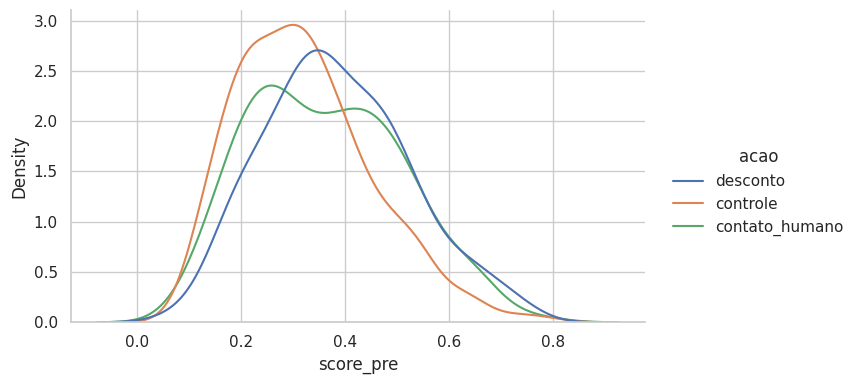

In [4]:
if SCORE_COLUMN in analysis.columns:
    plot_data = analysis[analysis[ACTION_COLUMN].isin([CONTROL_VALUE, *actions])]
    sns.displot(
        data=plot_data, x=SCORE_COLUMN, hue=ACTION_COLUMN,
        kind="kde", common_norm=False, height=4, aspect=1.7
    )
    plt.show()


## 4. DML: cada ação contra controle

Cada comparação usa somente clientes em um dos dois braços. `ml_g` estima churn condicional e `ml_m` estima a propensão da ação. O coeficiente é a diferença absoluta na probabilidade de churn (ação menos controle); valor negativo é redução de churn.

As comparações podem ter populações de overlap diferentes. Por isso, não interprete automaticamente o menor coeficiente como ranking perfeito entre ações.

In [5]:
def prepare_pair(data: pd.DataFrame, action: str):
    pair = data[data[ACTION_COLUMN].isin([CONTROL_VALUE, action])].copy()
    y = pair[OUTCOME_COLUMN].astype(int).to_numpy()
    d = pair[ACTION_COLUMN].eq(action).astype(int).to_numpy()
    x = pd.get_dummies(
        pair[FEATURE_COLUMNS], columns=CATEGORICAL_COLUMNS, drop_first=False, dtype=float
    )
    if not np.isfinite(x.to_numpy()).all():
        raise ValueError("Há valores não finitos nas covariáveis")
    clusters = pair[[CLUSTER_COLUMN]].to_numpy() if CLUSTER_COLUMN else None
    return pair, x, y, d, clusters

def fit_action(data: pd.DataFrame, action: str):
    pair, x, y, d, clusters = prepare_pair(data, action)
    dml_data = DoubleMLData.from_arrays(x=x, y=y, d=d, cluster_vars=clusters)
    outcome_model = HistGradientBoostingClassifier(
        max_iter=200, learning_rate=0.05, max_leaf_nodes=15,
        min_samples_leaf=30, random_state=RANDOM_STATE
    )
    propensity_model = LogisticRegression(
        C=0.5, max_iter=2_000, random_state=RANDOM_STATE
    )
    model = DoubleMLIRM(
        dml_data, ml_g=outcome_model, ml_m=propensity_model,
        n_folds=N_FOLDS, score="ATE", normalize_ipw=True,
        trimming_threshold=TRIMMING_THRESHOLD
    )
    model.fit(store_predictions=True)
    return model, pair, x

models = {}
rows = []
for action in actions:
    model, pair, x = fit_action(analysis, action)
    models[action] = model
    ci = model.confint(level=0.95).iloc[0]
    rows.append({
        "action": action, "n_pair": len(pair),
        "effect_action_minus_control": float(model.coef[0]),
        "std_error": float(model.se[0]),
        "ci95_low": float(ci.iloc[0]), "ci95_high": float(ci.iloc[1]),
        "p_value": float(model.pval[0]),
    })

results = pd.DataFrame(rows).sort_values("effect_action_minus_control")
display(results.round(4))


/tmp/ipykernel_42220/17841251.py:23: DeprecationWarning: 'trimming_threshold' is deprecated and will be removed in a future version. Use 'ps_processor_config' with 'clipping_threshold' instead.
  model = DoubleMLIRM(
/tmp/ipykernel_42220/17841251.py:23: DeprecationWarning: 'trimming_threshold' is deprecated and will be removed in a future version. Use 'ps_processor_config' with 'clipping_threshold' instead.
  model = DoubleMLIRM(


,action,n_pair,effect_action_minus_control,std_error,ci95_low,ci95_high,p_value
1,desconto,660,-0.0487,0.0368,-0.1208,0.0234,0.1853
0,contato_humano,680,-0.0405,0.0365,-0.1121,0.0311,0.2678


## 5. Propensão e sensibilidade

Propensões próximas de 0 ou 1 indicam extrapolação. O trimming estabiliza a estimativa, mas também muda a população-alvo. A análise de sensibilidade pergunta quão forte teria de ser um confundidor omitido para alterar a conclusão; ela não prova ausência de confundimento.

In [6]:
for action, model in models.items():
    propensity = np.asarray(model.predictions["ml_m"]).reshape(-1)
    print("\n", action, pd.Series(propensity).quantile([0, .01, .05, .5, .95, .99, 1]).to_dict())
    model.sensitivity_analysis(cf_y=0.03, cf_d=0.03, rho=1.0, level=0.95)
    print(model.sensitivity_summary)



 contato_humano {0.0: 0.19966119509615537, 0.01: 0.224386511730701, 0.05: 0.24902400086392928, 0.5: 0.33802589121302534, 0.95: 0.5084310476106336, 0.99: 0.5754745263838507, 1.0: 0.6575533996106109}
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
   CI lower  theta lower     theta  theta upper  CI upper
d -0.131337    -0.071173 -0.040469    -0.009765  0.050254

------------------ Robustness Values ------------------
   H_0    RV (%)   RVa (%)
d  0.0  3.935017  0.000542

 desconto {0.0: 0.12531631573943366, 0.01: 0.16933028500102232, 0.05: 0.19303982619344207, 0.5: 0.3215585067569793, 0.95: 0.5117714279354798, 0.99: 0.6099119354094183, 1.0: 0.6675427714644774}
================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Signif

## 6. Heterogeneidade pré-especificada

É mais seguro começar com poucos grupos definidos antes de olhar o resultado. `gate` estima efeitos por grupo usando os sinais ortogonais do DML. Grupos pequenos e muitas buscas geram descobertas espúrias.

In [7]:
GATE_FEATURE = FEATURE_COLUMNS[0]  # escolha uma característica pré-tratamento

for action, model in models.items():
    pair, _, _, _, _ = prepare_pair(analysis, action)
    group = pd.qcut(pair[GATE_FEATURE], q=3, duplicates="drop").astype(str)
    groups = pd.get_dummies(group, prefix=GATE_FEATURE, dtype=bool)
    gate = model.gate(groups=groups)
    print(f"\nGATE: {action} por {GATE_FEATURE}")
    display(gate.confint(level=0.95))



GATE: contato_humano por tenure


,2.5 %,effect,97.5 %
"tenure_(0.999, 13.0]",-0.101873,0.022700,0.147274
"tenure_(13.0, 23.0]",-0.254719,-0.128378,-0.002037
"tenure_(23.0, 54.0]",-0.140223,-0.020394,0.099436



GATE: desconto por tenure


,2.5 %,effect,97.5 %
"tenure_(0.999, 12.0]",-0.148967,-0.019560,0.109847
"tenure_(12.0, 24.0]",-0.209431,-0.089021,0.031388
"tenure_(24.0, 54.0]",-0.157624,-0.033367,0.090891


## 7. Decisão e limites

Uma ação com efeito `-0,03` reduz churn em aproximadamente 3 pontos percentuais na população identificada. Para decisão, combine o efeito com LTV e custo: `valor incremental = -LTV × efeito - custo`. Não use o p-valor como regra única.

Antes de recomendar ações: (1) audite temporalidade das features; (2) avalie balanceamento/overlap; (3) ajuste inferência por clusters; (4) defina uma exposição de rede se houver interferência; (5) faça sensibilidade; e (6) teste a política prospectivamente. Se ações e churn variam ao longo do tempo, considere MSM/g-formula em vez deste modelo de decisão única.